# Part 1: Face recognition from a database

In [14]:
import numpy as np
import h5py as h5
import matplotlib.pyplot as plt


## 1. Load the face database

The database contains 200 training images, 80 validation images, and 120 test images. Each image is 64 x 64 pixels; labels identify one of 40 subjects.


In [15]:
data_file = "facedb.hdf5"

with h5.File(data_file, "r") as hf:
    train_images = np.stack([hf["train"][f"face{i}"][:] for i in range(200)])
    valid_images = np.stack([hf["valid"][f"face{i}"][:] for i in range(80)])
    test_images = np.stack([hf["test"][f"face{i}"][:] for i in range(120)])

    train_labels = hf["trainLabels"][:]
    valid_labels = hf["validLabels"][:]
    test_labels = hf["testLabels"][:]

print("Images:", train_images.shape, valid_images.shape, test_images.shape)
print("Labels:", train_labels.shape, valid_labels.shape, test_labels.shape)


Images: (200, 64, 64) (80, 64, 64) (120, 64, 64)
Labels: (200,) (80,) (120,)


## Display the first six faces from each set

Shows the first 6 faces from each set to help see what the data looks like

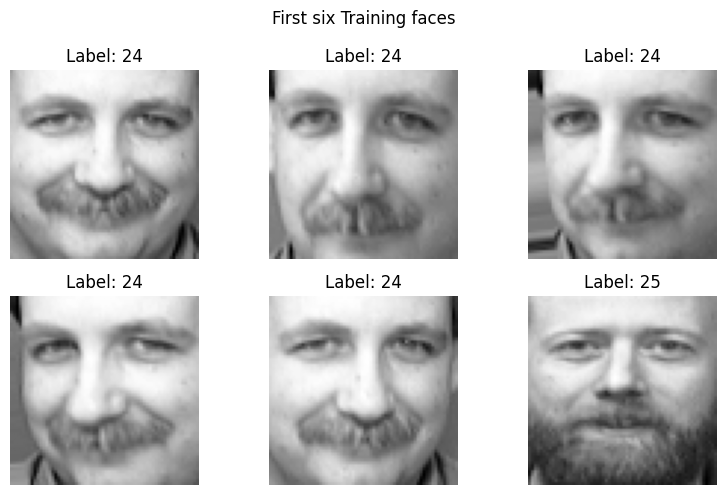

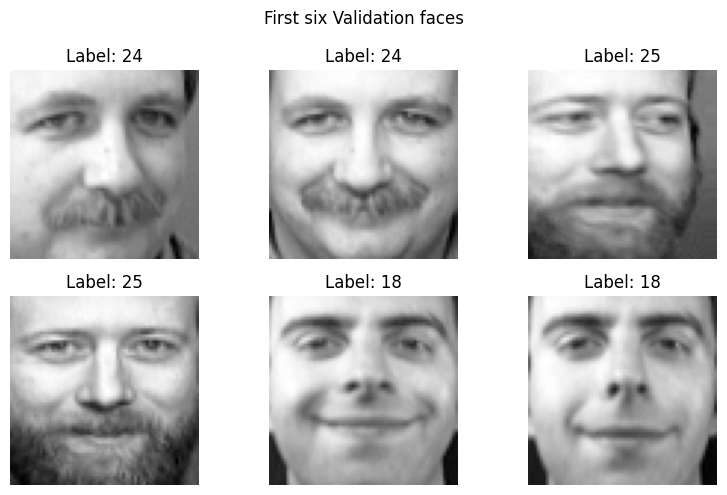

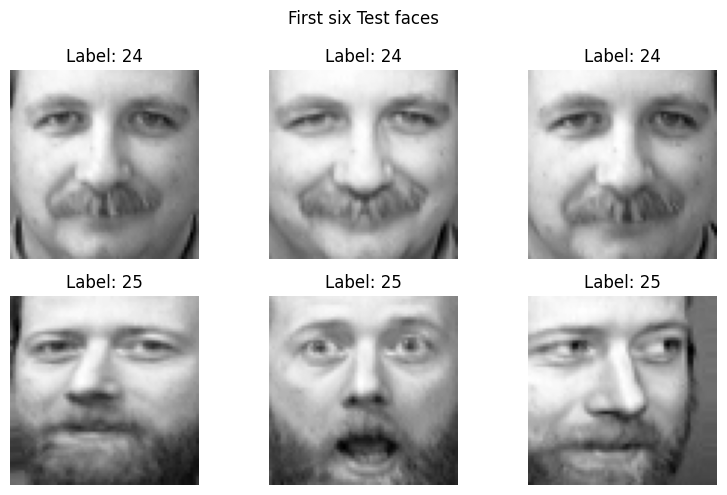

In [16]:
for name, images, labels in [("Training", train_images, train_labels),
                              ("Validation", valid_images, valid_labels),
                              ("Test", test_images, test_labels)]:
    fig, axes = plt.subplots(2, 3, figsize=(8, 5))
    fig.suptitle(f"First six {name} faces")
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i], cmap="gray")
        ax.set_title(f"Label: {labels[i]}")
        ax.axis("off")
    fig.tight_layout()
    plt.show()


## Prepare flattened face vectors

Each 64 x 64 image can be represented as a 4096 element vector. These arrays are the raw pixel features, these vectors are used for PCA below.


In [17]:
X_train = train_images.reshape(len(train_images), -1)
X_valid = valid_images.reshape(len(valid_images), -1)
X_test = test_images.reshape(len(test_images), -1)

print("Feature matrices:", X_train.shape, X_valid.shape, X_test.shape)


Feature matrices: (200, 4096) (80, 4096) (120, 4096)


## 2. Principal component analysis

Calculate the training covariance and sort the eigenvectors by decreasing eigenvalue.

This code finds the average training face and subtracts it from each training image. Calculates the covariance matrix, which describes how the pixel values vary.

$$ C_{xx} = \frac{1}{N} \sum_{i=1}^{N} (x_i - \mu_x) (x_i - \mu_x)^T $$

It then finds the eigenvectors and sorts them by decreasing eigenvalues.

In [ ]:
N, dim = X_train.shape
train_mean = np.mean(X_train, axis=0)
X_train_zero = X_train.astype(float) - train_mean

Sigma = (X_train_zero.T @ X_train_zero) / N
eigenvalues, eigenvectors = np.linalg.eig(Sigma)

# The covariance is real and symmetric, discard numerical imaginary noise.
eigenvalues = eigenvalues.real
eigenvectors = eigenvectors.real
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
V = eigenvectors[:, order]
print("PCA matrix shape:", V.shape)

PCA matrix shape: (4096, 4096)


## 3. Eigenvalues and choice of K

This plots the eigenvalues to see how much variation each PCA component represents. We keep the largest so that we use fewer features while retaining much of the training variation. We use 40 components (K=40), retaining around 87.3% of training variation (see below). 

$$ \text{Retained Variation} = \frac{\sum_{i=1}^{40} \lambda_i}{\sum_{j=1}^{n} \lambda_j} \cdot 100\% $$
Where n is equal to the number of meaningful eigenvalues

QDA uses four because of its limited training data. There are only 5 training faces per subject.

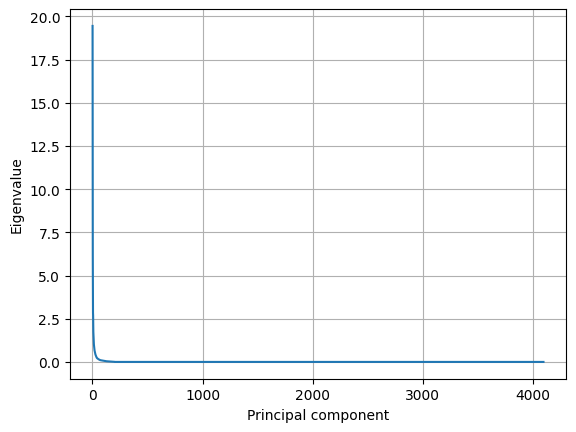

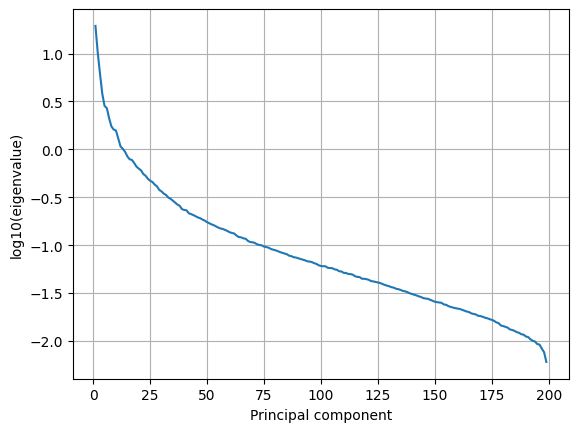

K: 40
Retained variance: 0.872861642919886


In [19]:
tolerance = np.finfo(float).eps * dim * eigenvalues[0]
positive = eigenvalues > tolerance
rank = np.sum(positive)

plt.figure()
plt.plot(np.arange(1, dim + 1), eigenvalues)
plt.xlabel("Principal component")
plt.ylabel("Eigenvalue")
plt.grid()
plt.show()

plt.figure()
plt.plot(np.arange(1, rank + 1), np.log10(eigenvalues[positive]))
plt.xlabel("Principal component")
plt.ylabel("log10(eigenvalue)")
plt.grid()
plt.show()

K = 40
K_qda = 4
print("K:", K)
print("Retained variance:", np.sum(eigenvalues[:K]) / np.sum(eigenvalues[positive]))

## 4. PCA transformation

Convert each face from 4096 pixel values into its PCA features. Apply the same training mean and eigenvectors to all three sets so their features are calculated the same way.

In [20]:
V_K = V[:, :K]
X_train_pca = X_train_zero @ V_K
X_valid_pca = (X_valid - train_mean) @ V_K
X_test_pca = (X_test - train_mean) @ V_K

V_qda = V[:, :K_qda]
X_train_qda = X_train_zero @ V_qda
X_test_qda = (X_test - train_mean) @ V_qda

## 5. Linear discriminant analysis

Calculate an average feature vector for each subject. LDA uses one shared covariance matrix to describe the variation within subjects. For an input face, calculate each subjects score:

$$ y_i(x) = \mu_i^T \Sigma^{-1} x + \ln P(\omega_i) - \frac{1}{2} \mu_i^T \Sigma^{-1} \mu_i $$
Where $x$ is the faces PCA feature vector, $\mu_i$ is the mean feature vector for the subject, $P(\omega_i)$ is the subjects prior probability and the output is the subject with the highest $y_i(x)$

For an input face, calculate a score for every subject and predict the subject with the highest score.

In [21]:
def computeLDA(x, Sigma_inverse, mu, prior):
    mu2 = mu[:, None]
    x2 = x[:, None]
    y = mu2.T @ Sigma_inverse @ x2 + np.log(prior) - 0.5 * mu2.T @ Sigma_inverse @ mu2
    return y.item()


def trainLDA(data, labels):
    classes = np.unique(labels)
    means = []
    priors = []
    Sigma = np.zeros((data.shape[1], data.shape[1]))

    for subject in classes:
        subject_data = data[labels == subject]
        N_subject = len(subject_data)
        means.append(np.mean(subject_data, axis=0))
        priors.append(N_subject / len(labels))
        subject_covariance = np.cov(subject_data.T)
        Sigma += (N_subject - 1) * subject_covariance

    Sigma = Sigma / (len(labels) - len(classes))
    return classes, Sigma, np.array(means), np.array(priors), np.linalg.inv(Sigma)


def predictLDA(x, model):
    classes, Sigma, means, priors, Sigma_inverse = model
    scores = np.zeros(len(classes))
    for i in range(len(classes)):
        scores[i] = computeLDA(x, Sigma_inverse, means[i], priors[i])
    return classes[np.argmax(scores)]


lda_model = trainLDA(X_train_pca, train_labels)

## 6. Quadratic discriminant analysis

QDA works in a similar way to LDA, but each subject has their own covariance matrix $\Sigma_i$. Calculate each subjects score:

$$ y_i(x) = -\frac{1}{2} (x - \mu_i)^T \Sigma_i^{-1} (x - \mu_i) - \frac{1}{2} \ln |\Sigma_i| + \ln P(\omega_i) $$

Predict the subject with the highest score. With only five training faces per subject, we use four PCA components so the covariance matrices can be inverted.

In [22]:
def computeQDA(x, Sigma, mu, prior):
    mu2 = mu[:, None]
    x2 = x[:, None]
    y = -0.5 * np.log(np.linalg.det(Sigma)) - 0.5 * (x2 - mu2).T @ np.linalg.inv(Sigma) @ (x2 - mu2) + np.log(prior)
    return y.item()


def trainQDA(data, labels):
    classes = np.unique(labels)
    covariances = []
    means = []
    priors = []
    for subject in classes:
        subject_data = data[labels == subject]
        means.append(np.mean(subject_data, axis=0))
        priors.append(len(subject_data) / len(labels))
        Sigma = np.cov(subject_data.T)
        covariances.append(Sigma)
    return classes, np.array(covariances), np.array(means), np.array(priors)


def predictQDA(x, model):
    classes, covariances, means, priors = model
    scores = np.zeros(len(classes))
    for i in range(len(classes)):
        scores[i] = computeQDA(x, covariances[i], means[i], priors[i])
    return classes[np.argmax(scores)]


qda_model = trainQDA(X_train_qda, train_labels)

## 7. Logistic regression

Train logistic regression with several regularisation strengths. Regularisation limits how strongly the model fits the training data. Compare training and validation accuracy, then keep the model with the highest validation accuracy. 

The library uses $C = \frac{1}{\lambda}$.

We train several models and compare their validation accuracy, as seen within the plots below:

Best lambda: 0.0001
Validation accuracy: 0.925


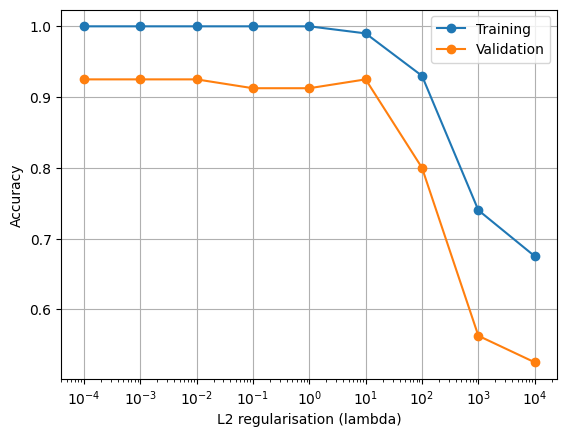

In [23]:
from sklearn.linear_model import LogisticRegression as LR

lambda_values = np.logspace(-4, 4, 9)
lr_train_accuracy = []
lr_valid_accuracy = []
lr_models = []

for regularisation in lambda_values:
    lr = LR(C=1 / regularisation, max_iter=5000)
    lr.fit(X_train_pca, train_labels)
    lr_models.append(lr)
    lr_train_accuracy.append(lr.score(X_train_pca, train_labels))
    lr_valid_accuracy.append(lr.score(X_valid_pca, valid_labels))

best_lr = np.argmax(lr_valid_accuracy)
lr = lr_models[best_lr]
print("Best lambda:", lambda_values[best_lr])
print("Validation accuracy:", lr_valid_accuracy[best_lr])

plt.figure()
plt.semilogx(lambda_values, lr_train_accuracy, "o-", label="Training")
plt.semilogx(lambda_values, lr_valid_accuracy, "o-", label="Validation")
plt.xlabel("L2 regularisation (lambda)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

## 8. Support vector machine

Trains several SVM models using different values of C. This parameter controls the balance between allowing training errors and fitting the training examples closely. Choose the value with the highest validation accuracy and plot both training and validation results.

Similarly to above, we train several models and plot their validation accuracy:

Best C: 1.0
Validation accuracy: 0.8875


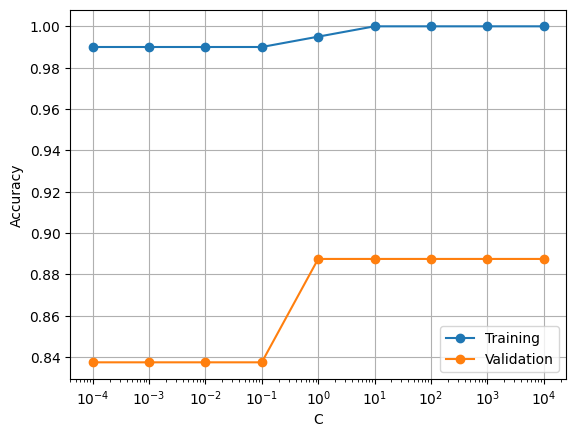

In [24]:
from sklearn.svm import SVC

C_values = np.logspace(-4, 4, 9)
svm_train_accuracy = []
svm_valid_accuracy = []
svm_models = []

for C in C_values:
    svc = SVC(C=C, gamma="auto")
    svc.fit(X_train_pca, train_labels)
    svm_models.append(svc)
    svm_train_accuracy.append(svc.score(X_train_pca, train_labels))
    svm_valid_accuracy.append(svc.score(X_valid_pca, valid_labels))

best_svm = np.argmax(svm_valid_accuracy)
svc = svm_models[best_svm]
print("Best C:", C_values[best_svm])
print("Validation accuracy:", svm_valid_accuracy[best_svm])

plt.figure()
plt.semilogx(C_values, svm_train_accuracy, "o-", label="Training")
plt.semilogx(C_values, svm_valid_accuracy, "o-", label="Validation")
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

## 9. Test accuracy

Use the trained classifiers to predict the identities of the test faces. Compare those predictions with the correct labels. Accuracy is the number of correct predictions divided by the total number of test faces.

Evaluates the selected models on unseen test faces by comparing their predictions with the correct labels.

In [25]:
lda_predictions = np.array([predictLDA(x, lda_model) for x in X_test_pca])
qda_predictions = np.array([predictQDA(x, qda_model) for x in X_test_qda])
lr_predictions = lr.predict(X_test_pca)
svm_predictions = svc.predict(X_test_pca)

predictions = {"LDA": lda_predictions, "QDA": qda_predictions,
               "LR": lr_predictions, "SVM": svm_predictions}
for name, prediction in predictions.items():
    accuracy = np.sum(prediction == test_labels) / len(test_labels)
    print(name, "test accuracy:", accuracy)

LDA test accuracy: 0.9166666666666666
QDA test accuracy: 0.325
LR test accuracy: 0.9083333333333333
SVM test accuracy: 0.85


## 10. Misclassified faces

This finds the test faces each classifier labeled incorrectly. It displays each one beside an example of its correct subject. Looking at the tests some mistakes are clearly noticeable such as these from the LDA:

**Test 23:** The head angle is noticeably different from the correct subject reference image.

**Test 71:** The test face looks sideways, while the reference looks more directly forward.

**Test 76 & 77:** The test faces have no glasses, while the correct subject reference wears glasses.

All possible contributors but not directly proven reasons, the reference is another photograph of the same subject, not an image the classifier directly matched against.

LDA incorrect faces: 10


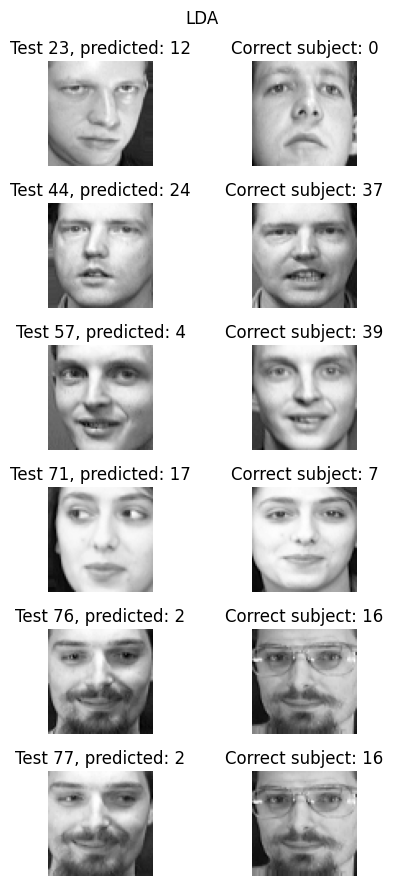

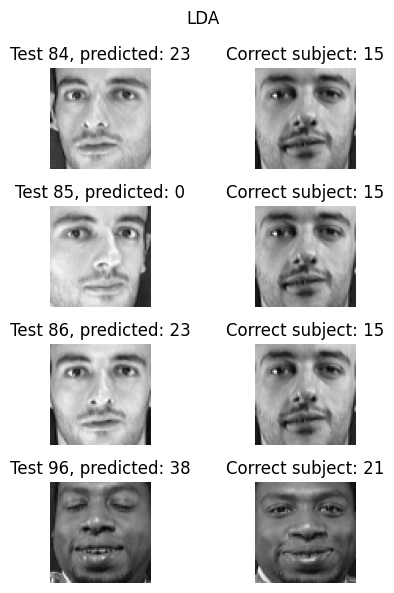

QDA incorrect faces: 81


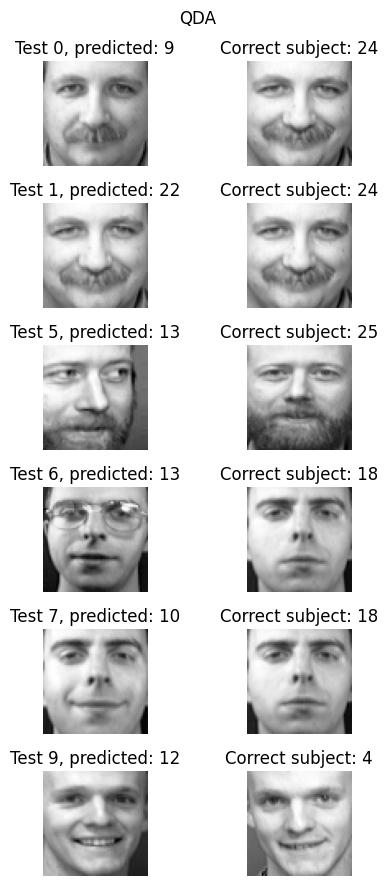

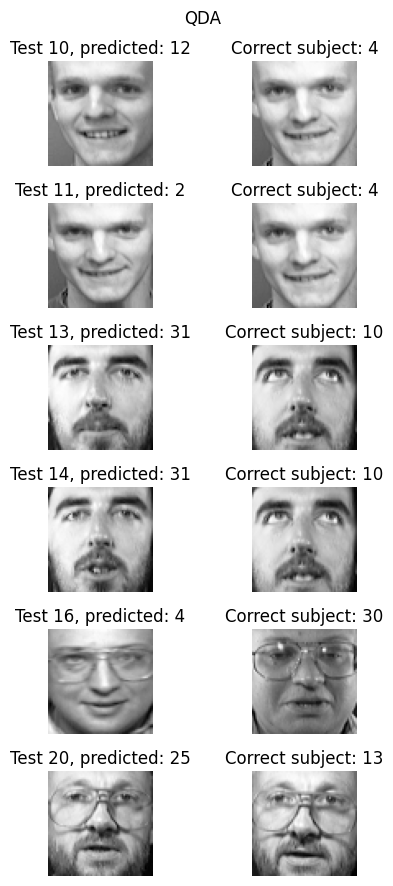

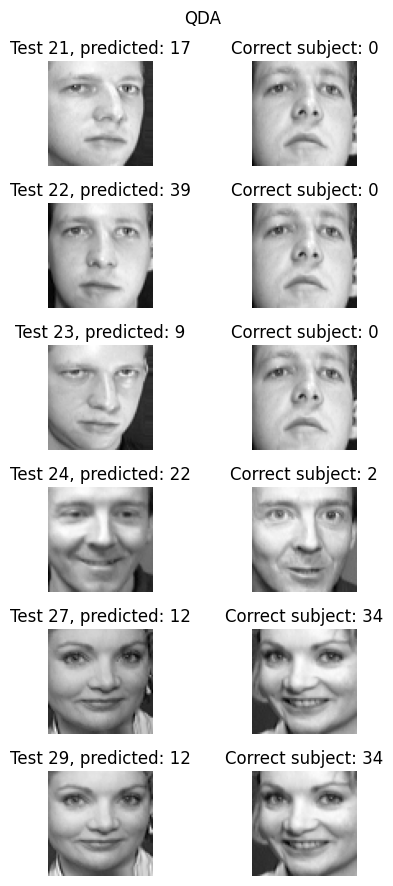

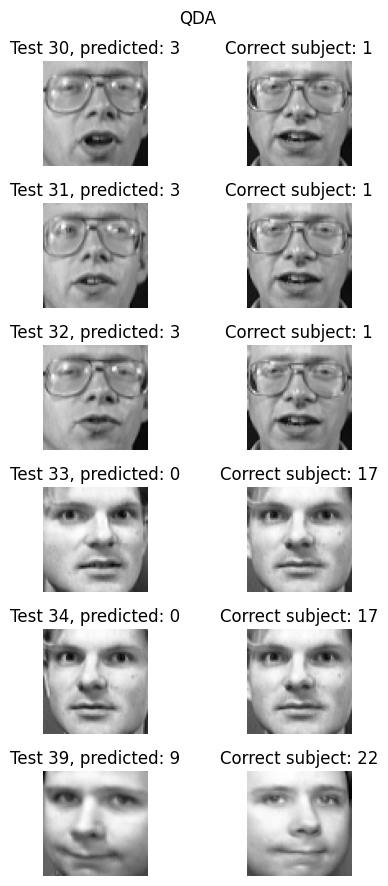

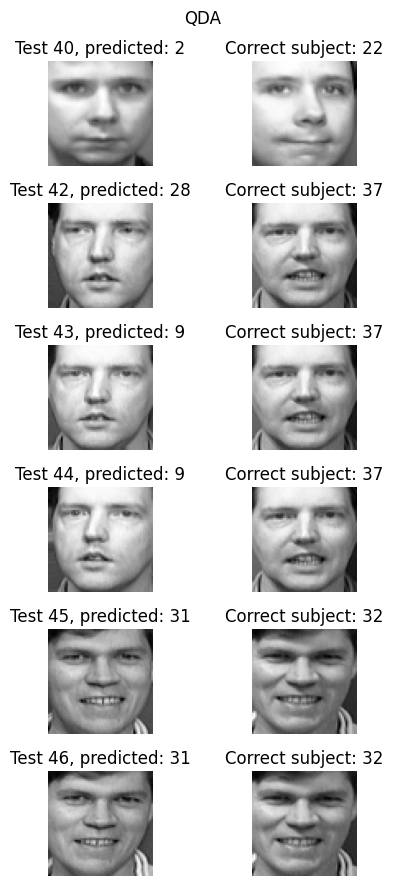

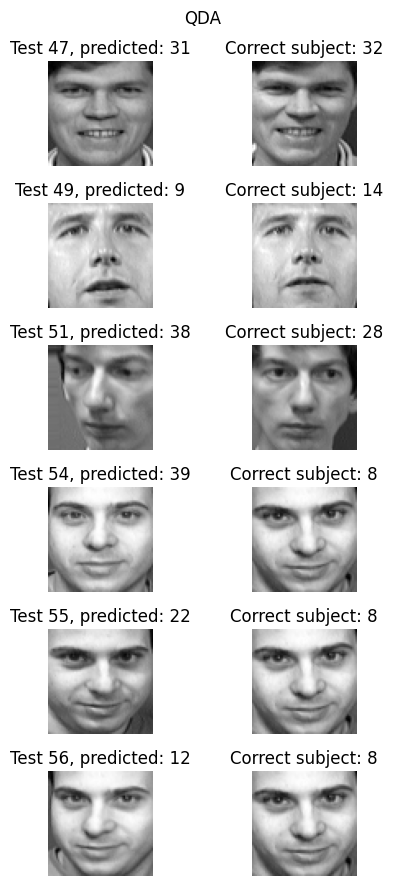

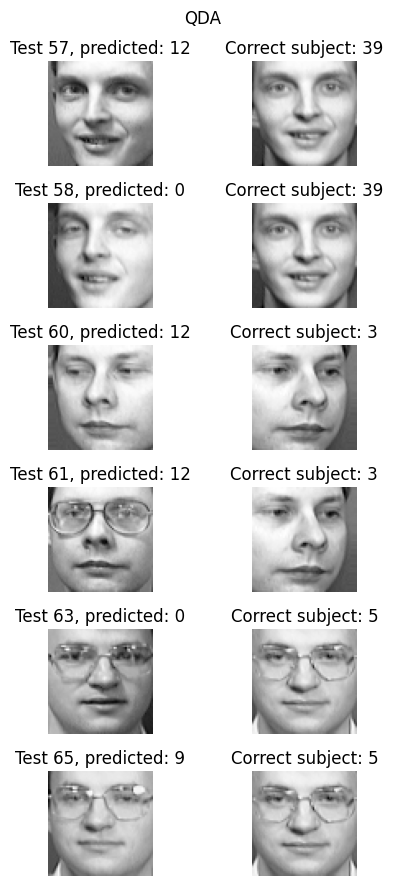

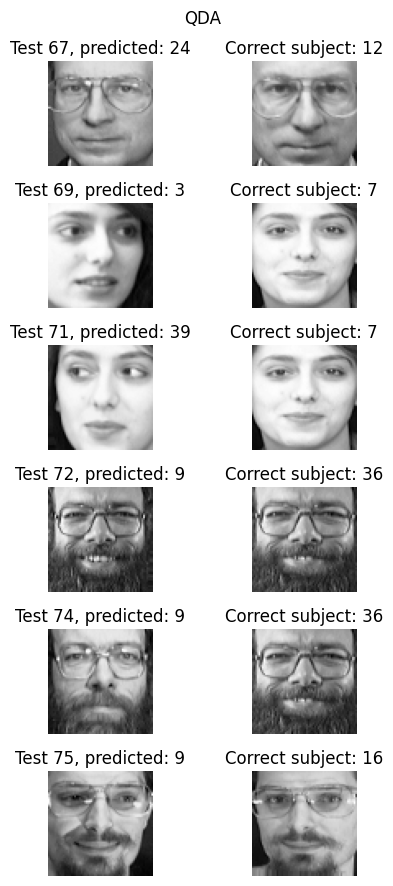

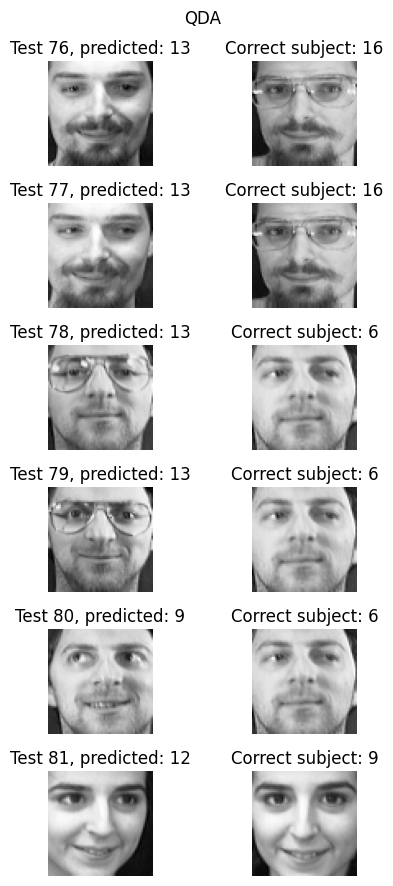

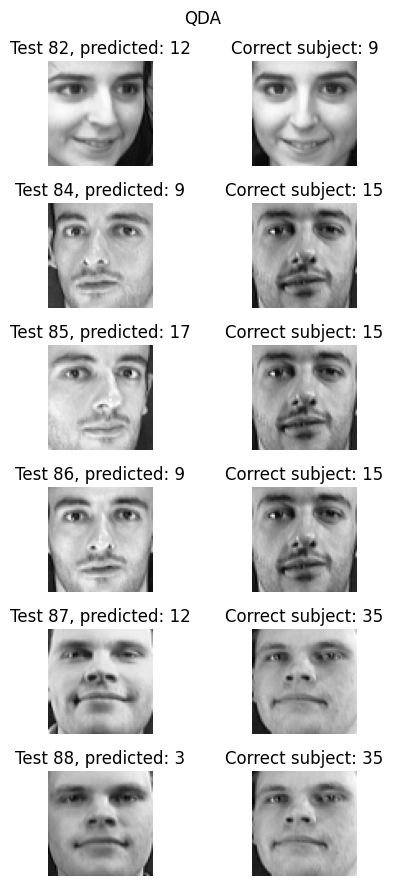

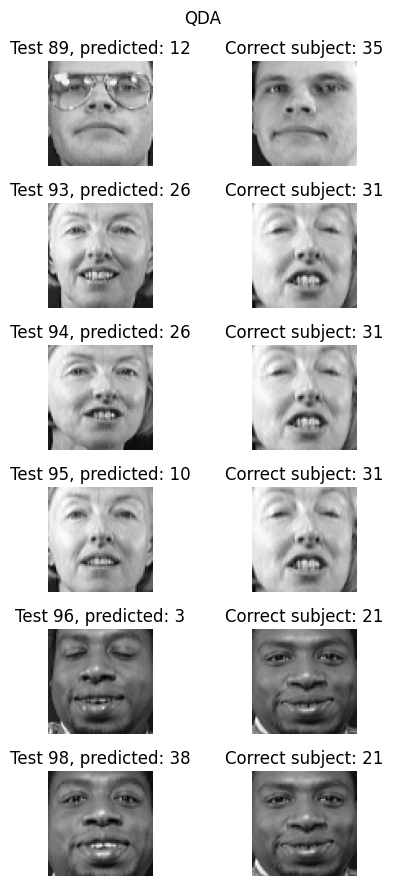

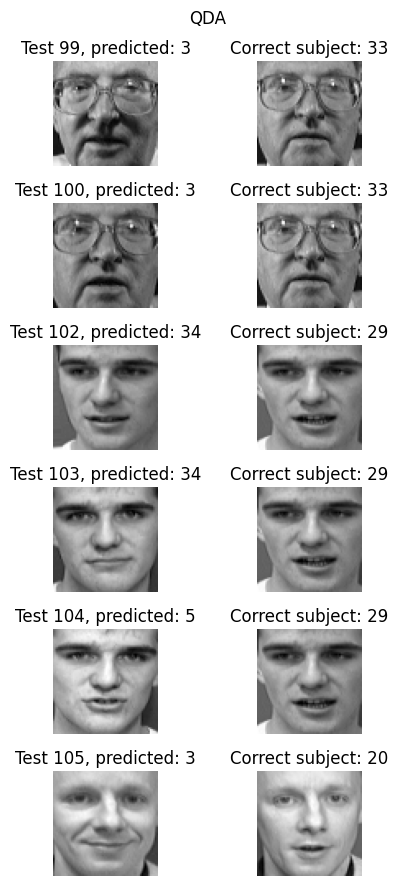

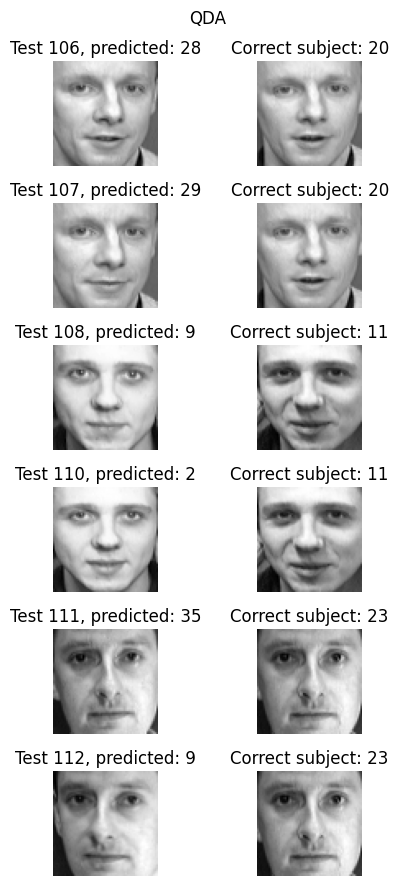

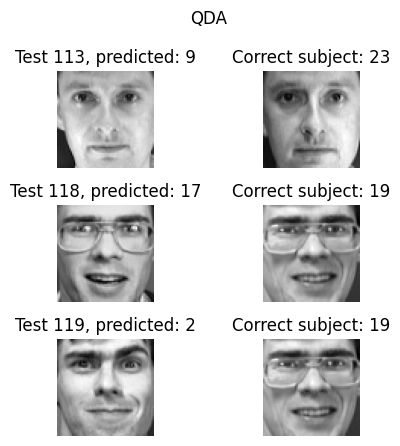

LR incorrect faces: 11


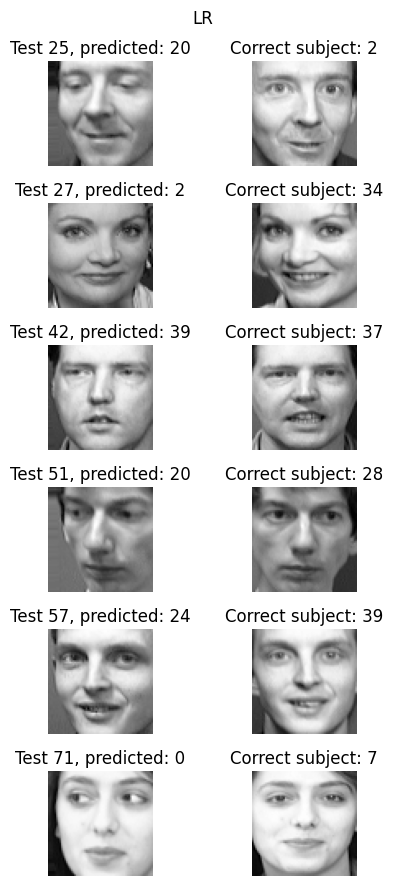

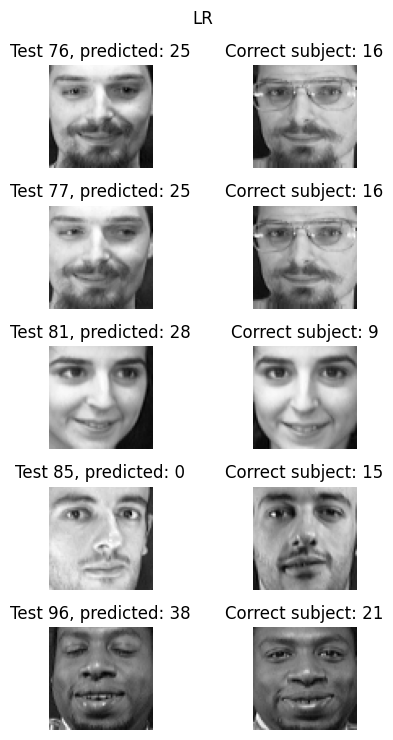

SVM incorrect faces: 18


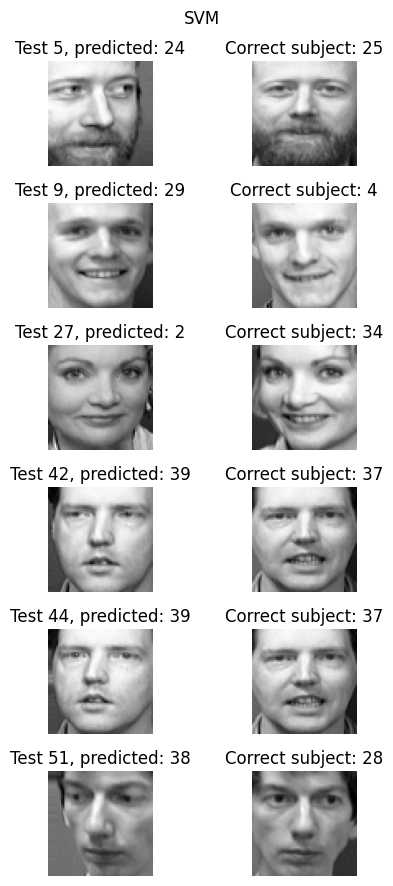

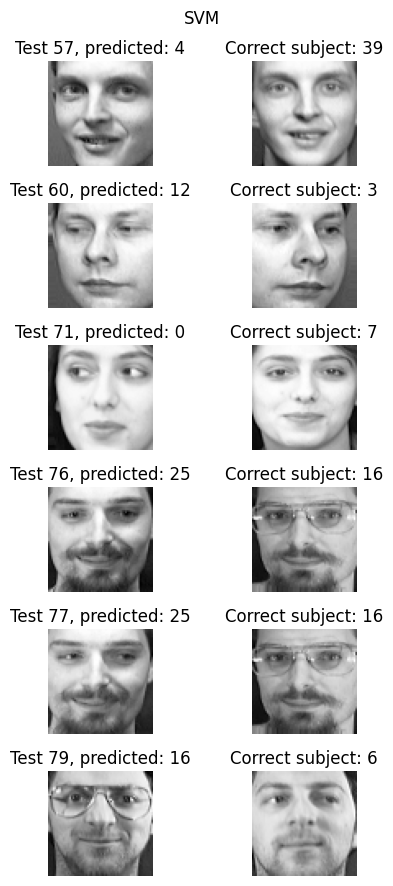

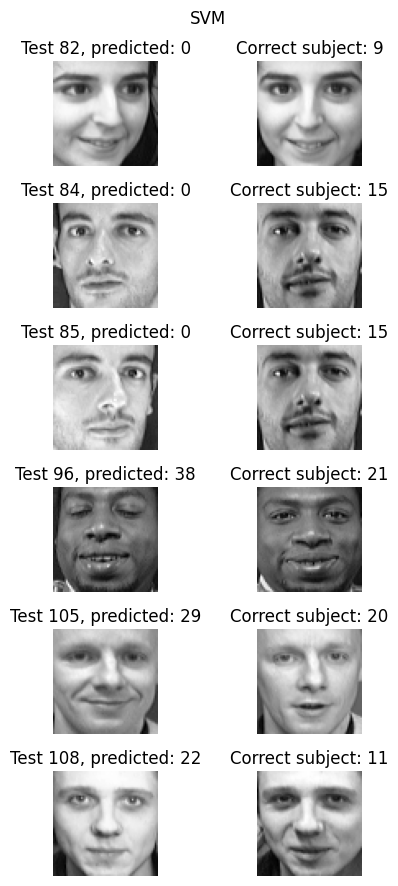

In [26]:
for name, prediction in predictions.items():
    wrong = np.flatnonzero(prediction != test_labels)
    print(name, "incorrect faces:", len(wrong))

    for start in range(0, len(wrong), 6):
        indices = wrong[start:start + 6]
        fig, axes = plt.subplots(len(indices), 2, figsize=(5, 1.5 * len(indices)), squeeze=False)
        fig.suptitle(name)
        for row, index in enumerate(indices):
            correct_index = np.flatnonzero(train_labels == test_labels[index])[0]
            axes[row, 0].imshow(test_images[index], cmap="gray")
            axes[row, 0].set_title(f"Test {index}, predicted: {prediction[index]}")
            axes[row, 1].imshow(train_images[correct_index], cmap="gray")
            axes[row, 1].set_title(f"Correct subject: {test_labels[index]}")
            axes[row, 0].axis("off")
            axes[row, 1].axis("off")
        fig.tight_layout()
        plt.show()

### Discussion

LDA achieved the highest test accuracy of 91.7%, followed closely by logistic regression at 90.8%. SVM achieved 85%, while QDA only got to 32.5%. QDA only used four PCA components and estimated each subjects covariance from five training faces, which likely contributed to the poor performance. Because other classifiers used 40 components, this comparison also reflects differences in the information available to each classifier.